# **Project:** <a href="https://github.com/apdoolhamza/BankMate-AI/blob/main/Project_Documentation.pdf">Documentation</a> | <a href="https://huggingface.co/spaces/apdoolhamza/BankMate-Bot">Live Demo</a> | <a href="https://github.com/apdoolhamza/BankMate-AI">GitHub</a>

# Install & Import packages

In [ ]:
!pip install -q wordcloud seaborn scikit-learn pandas matplotlib joblib sentence-transformers

print("Setup ready")

Setup ready


In [ ]:
import pandas as pd
import numpy as np
import json
import random
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

sns.set(style="whitegrid")

# Load Data

CSV_PATH = "/content/bankmate_intents_data.csv"

df = pd.read_csv(CSV_PATH)

print(f"\nTotal examples: {len(df):,}")
print("\nClass distribution:")
print(df['intent'].value_counts())


Total examples: 223

Class distribution:
intent
greeting                  50
balance_inquiry_guide     28
transfer_guide            22
card_lost_guide           16
loan_application_guide    15
bill_payment_guide        14
goodbye                   14
fraud_report_guide        12
airtime_topup_guide       12
human_agent               12
atm_branch_guide          10
complaint_guide            9
ussd_help                  9
Name: count, dtype: int64


# Visualization 1: Class Distribution

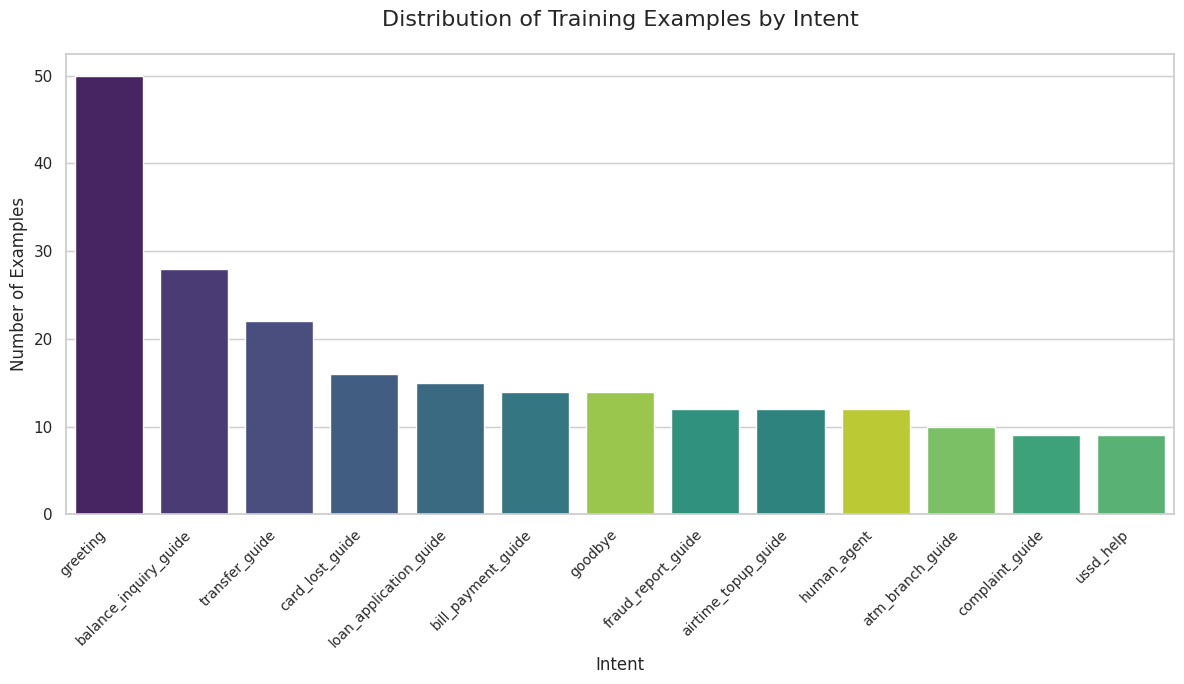

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='intent', hue='intent', order=df['intent'].value_counts().index, palette='viridis')
plt.title("Distribution of Training Examples by Intent", fontsize=16, pad=20)
plt.xlabel("Intent", fontsize=12)
plt.ylabel("Number of Examples", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Train / Test Split

In [ ]:
X = df['text']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {len(X_train):,}   Test: {len(X_test):,}")


Train: 167   Test: 56


# Build & Train Pipeline

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 3),
        min_df=1,
        stop_words='english'
    )),
    ('clf', LogisticRegression(
        solver='lbfgs',
        max_iter=2000,
        random_state=42,
        class_weight='balanced'
    ))
])

print("\nTraining model...")
pipeline.fit(X_train, y_train)
print("Training complete.")


Training model...
Training complete.


# Evaluation + Visualizations

In [ ]:
y_pred = pipeline.predict(X_test)

print("\nAccuracy: {:.2%}".format(accuracy_score(y_test, y_pred)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 92.86%

Classification Report:
                        precision    recall  f1-score   support

   airtime_topup_guide       1.00      1.00      1.00         3
      atm_branch_guide       1.00      1.00      1.00         2
 balance_inquiry_guide       1.00      0.86      0.92         7
    bill_payment_guide       1.00      1.00      1.00         4
       card_lost_guide       1.00      1.00      1.00         4
       complaint_guide       0.00      0.00      0.00         2
    fraud_report_guide       0.60      1.00      0.75         3
               goodbye       1.00      1.00      1.00         3
              greeting       1.00      0.92      0.96        13
           human_agent       0.75      1.00      0.86         3
loan_application_guide       1.00      1.00      1.00         4
        transfer_guide       1.00      1.00      1.00         6
             ussd_help       0.67      1.00      0.80         2

              accuracy                           0.93       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Visualization 2: Confusion Matrix

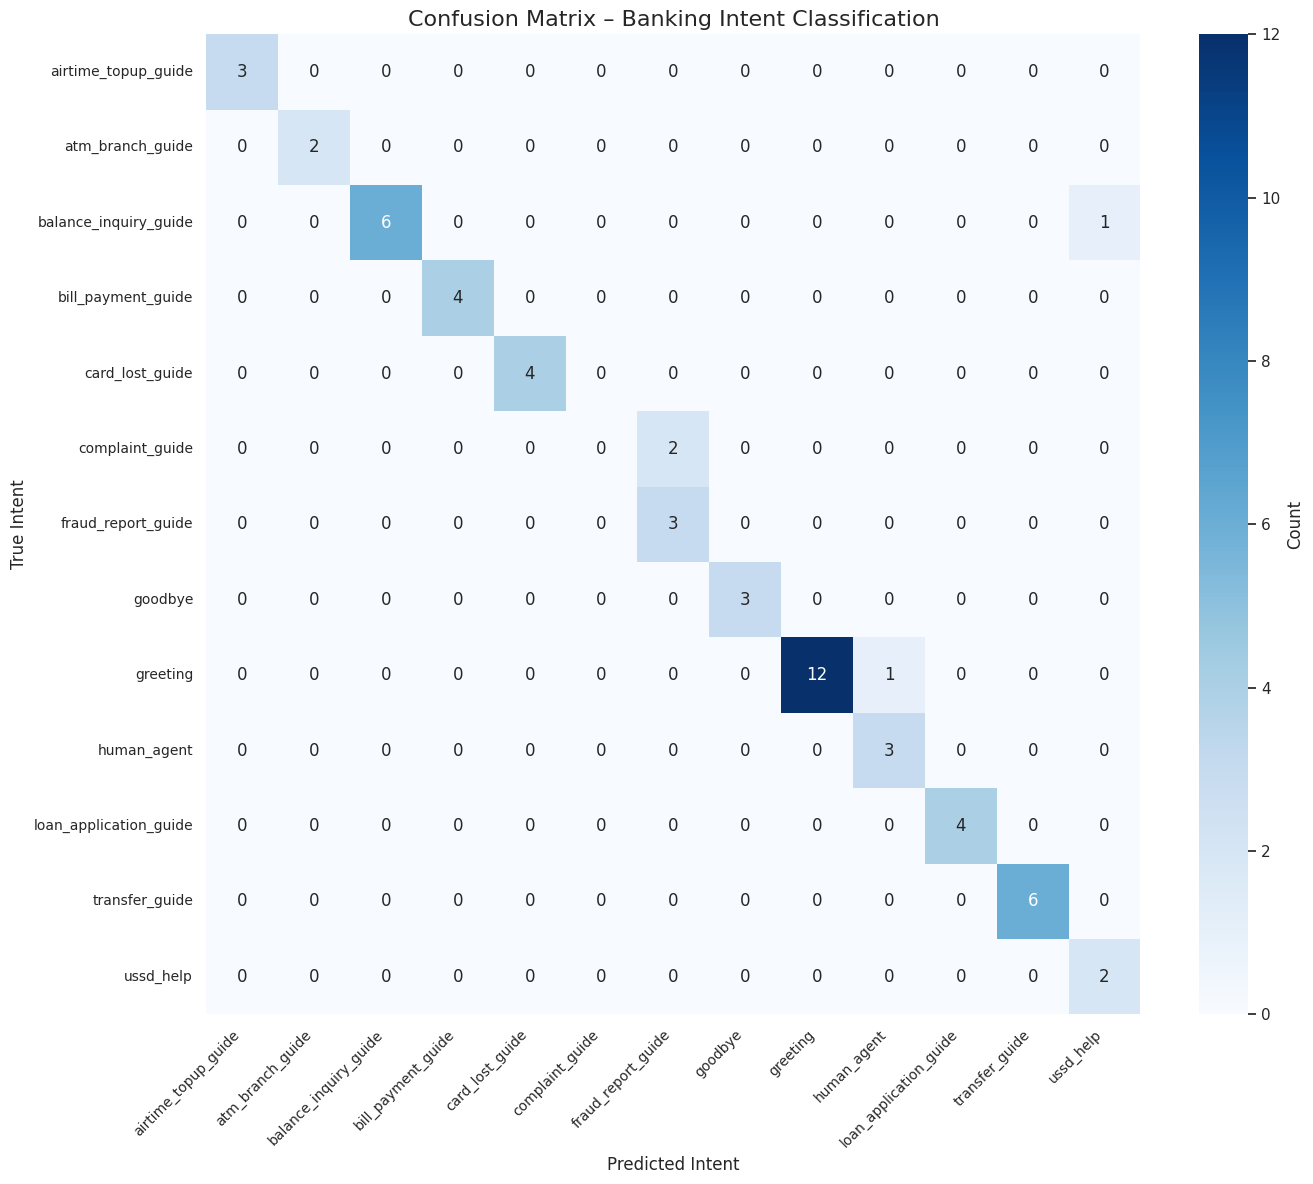

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_,
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix – Banking Intent Classification", fontsize=16)
plt.xlabel("Predicted Intent", fontsize=12)
plt.ylabel("True Intent", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Visualization 3: Top Features per Intent

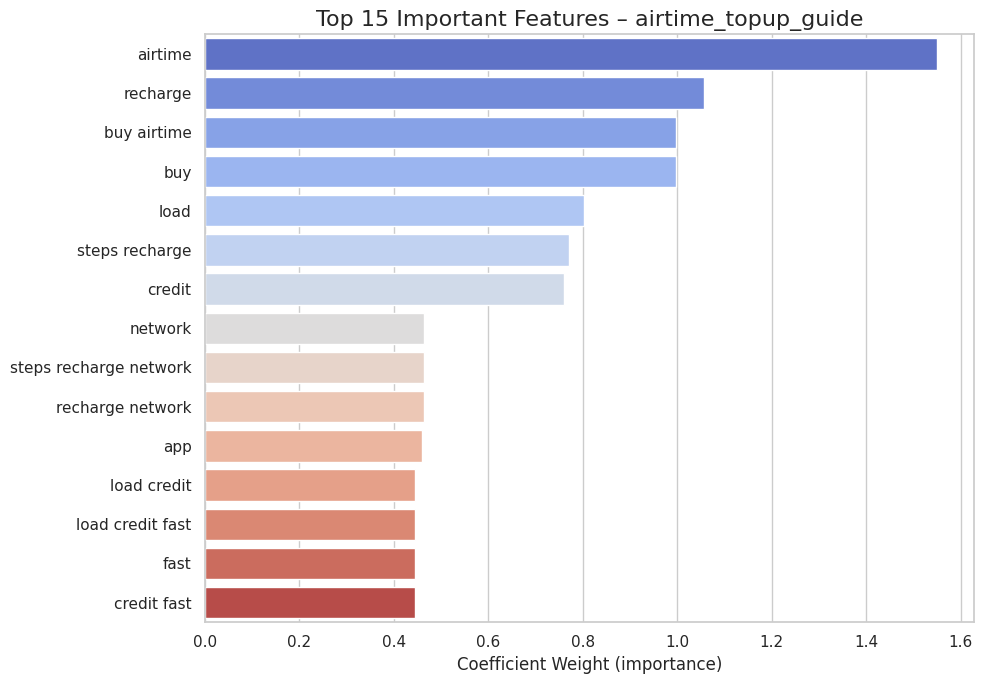

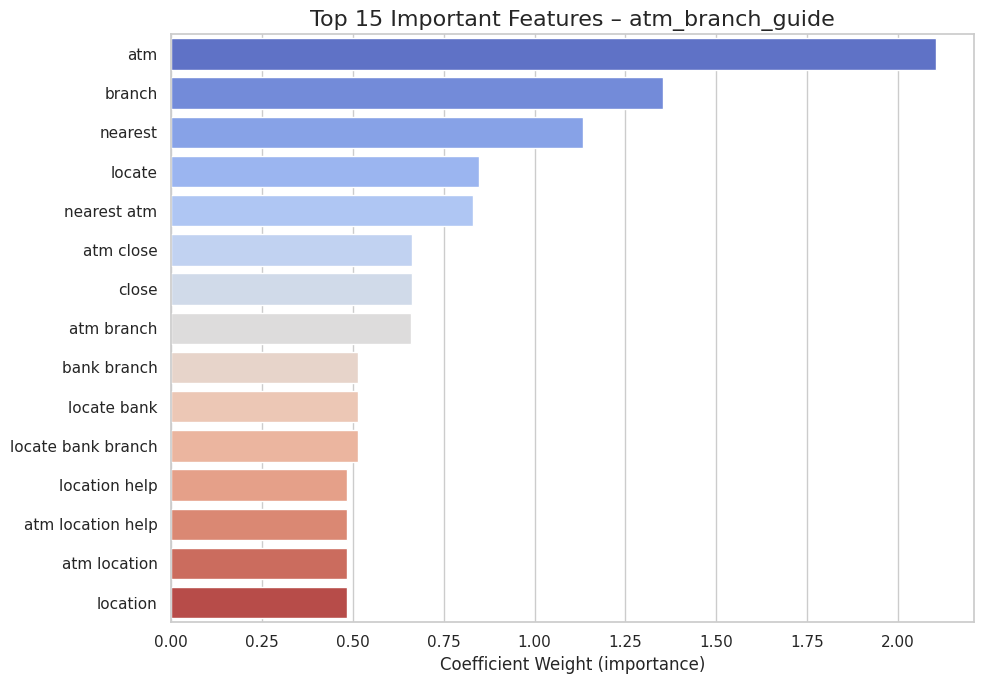

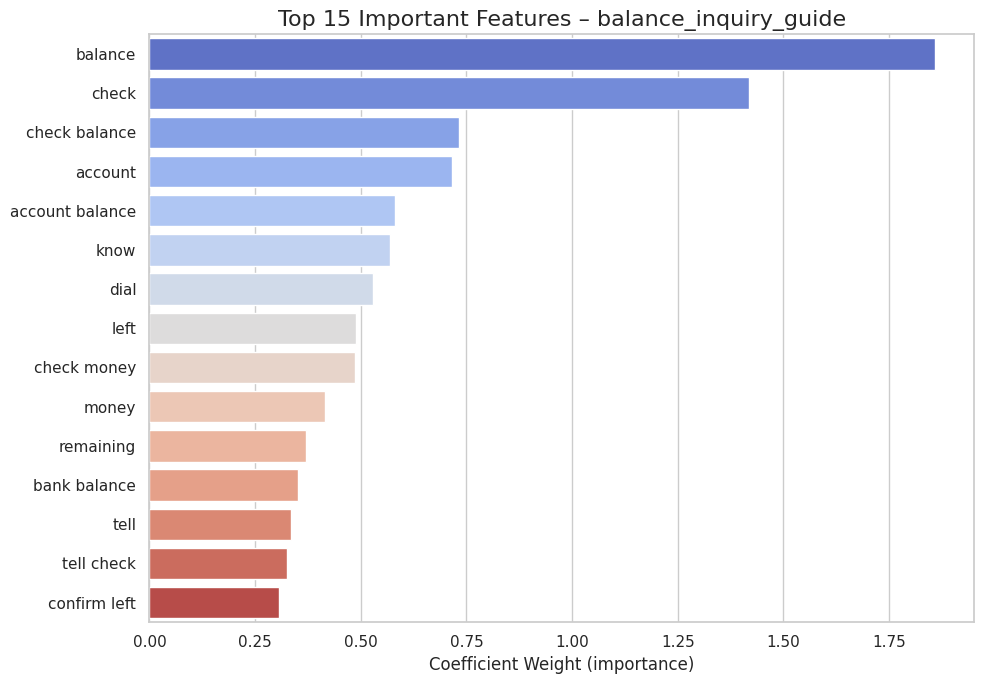

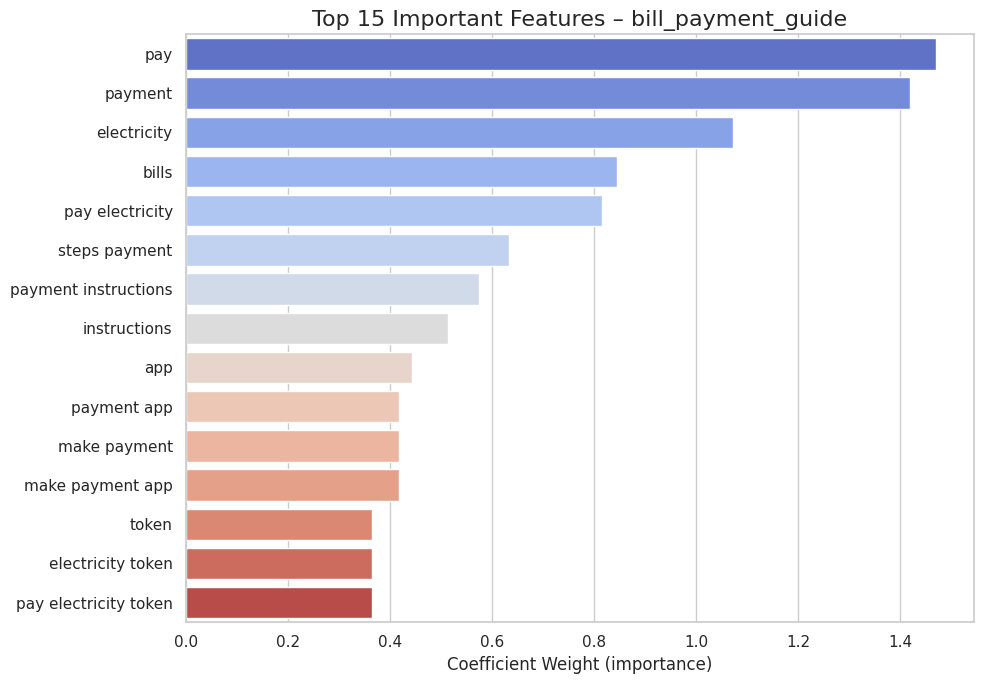

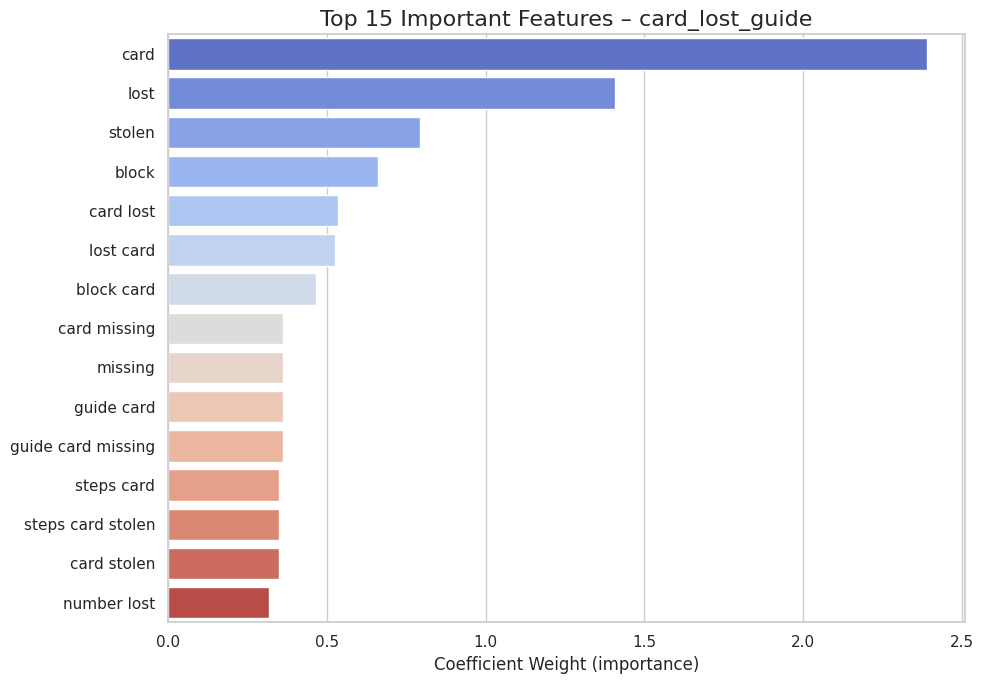

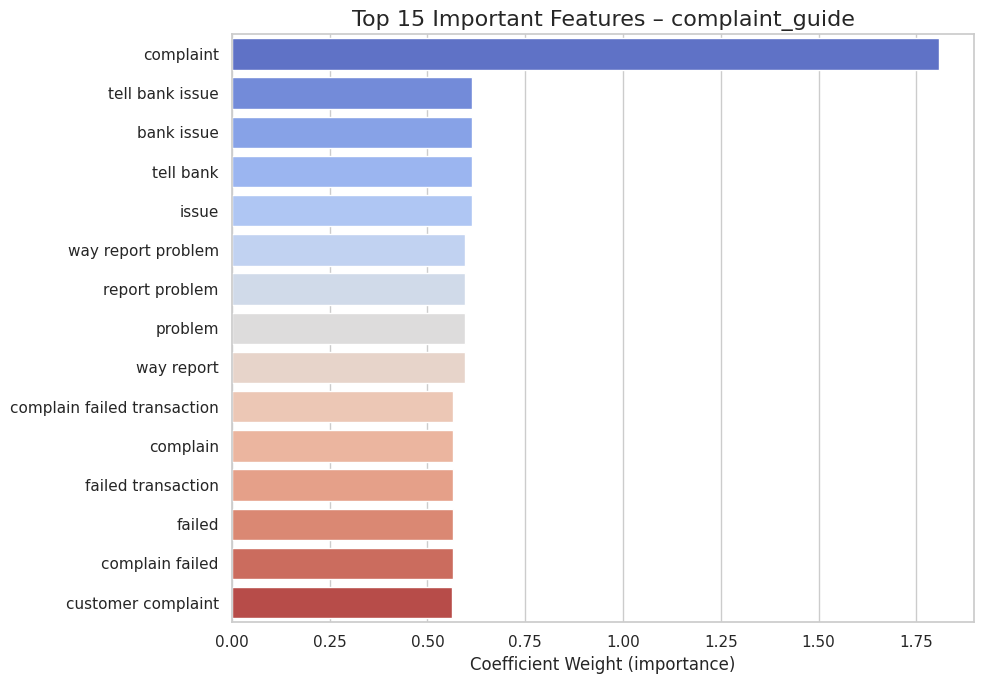

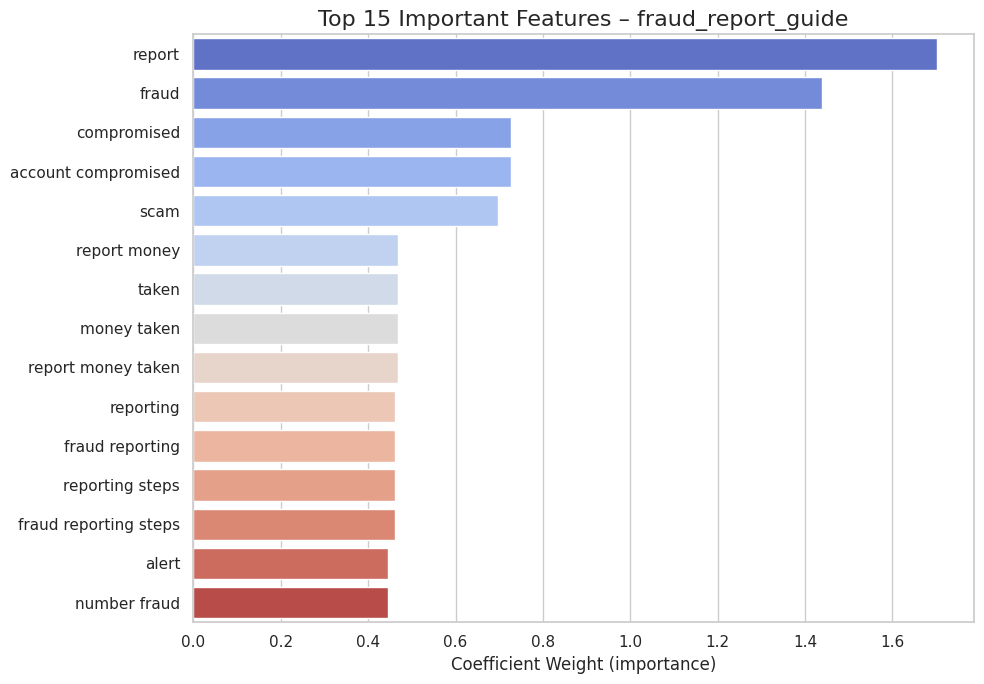

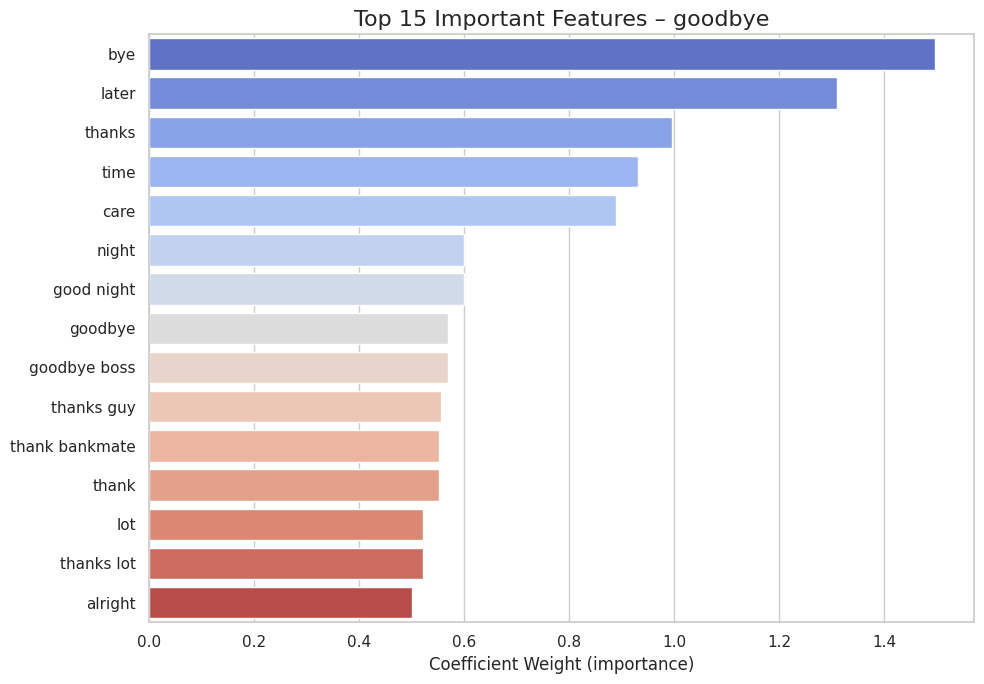

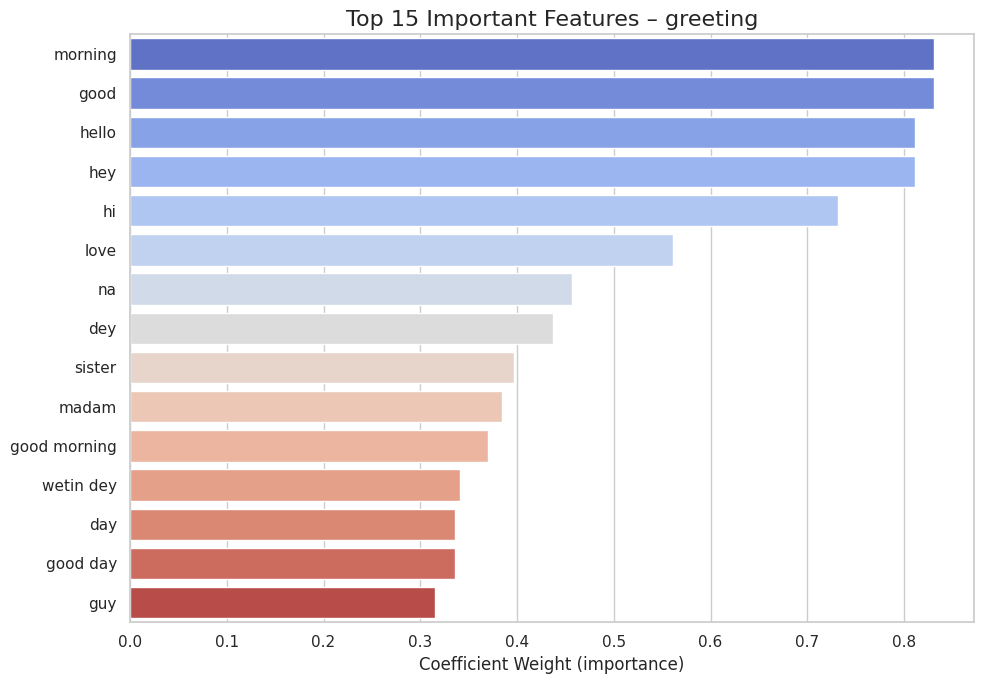

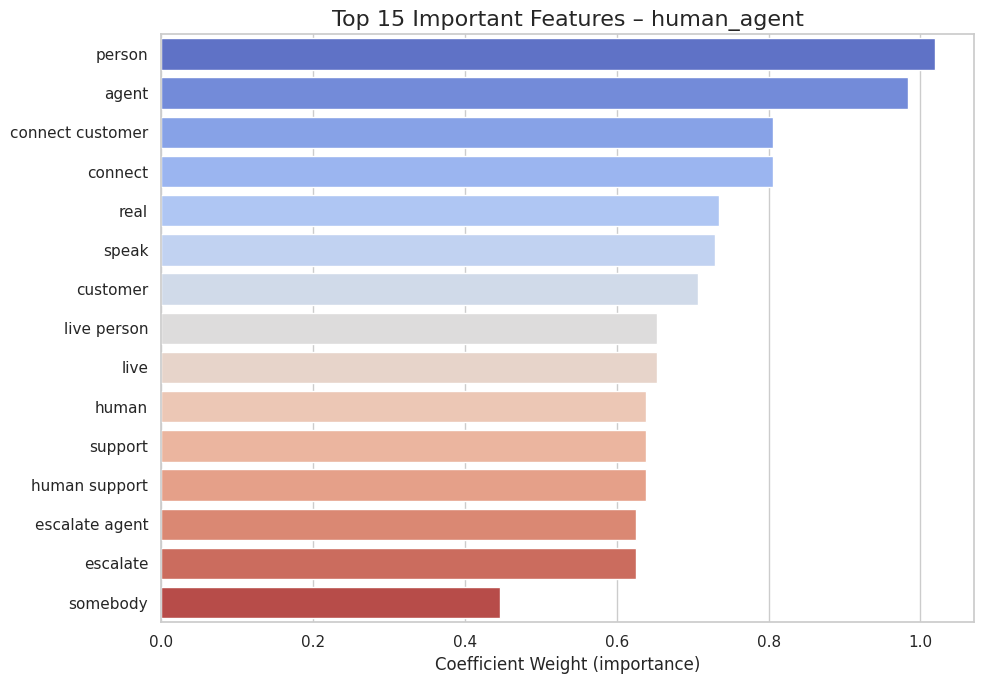

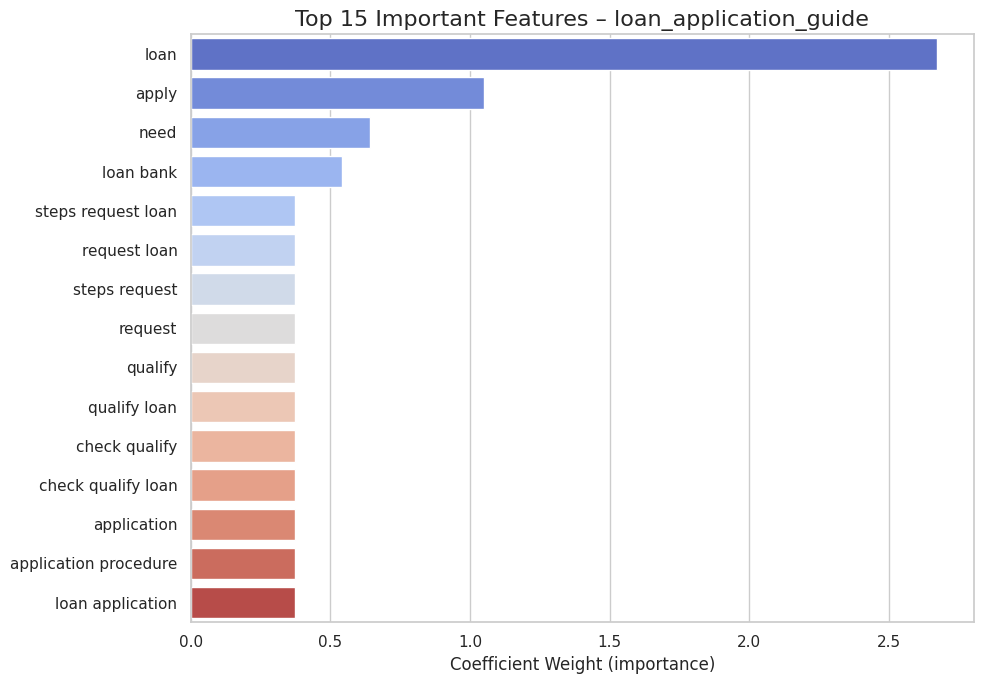

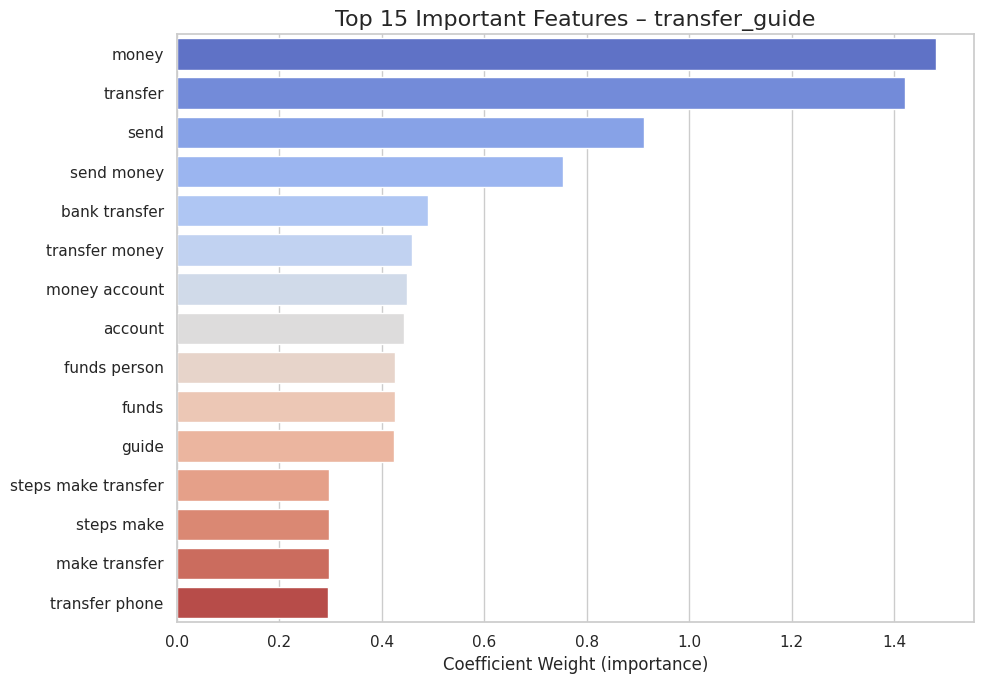

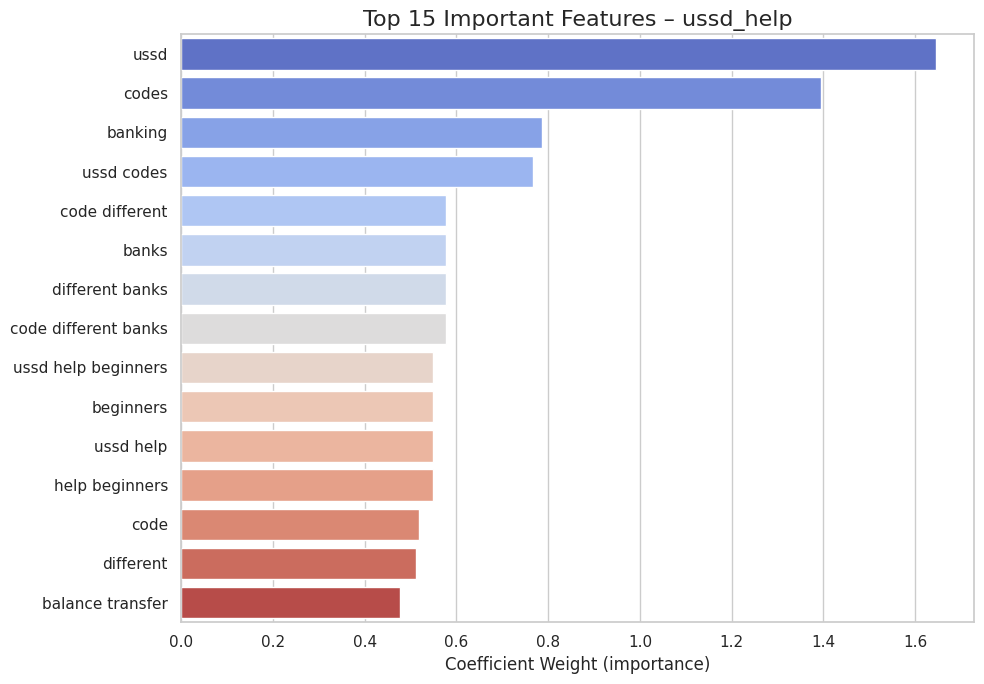

In [ ]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef = pipeline.named_steps['clf'].coef_

for i, intent in enumerate(pipeline.classes_):
    top_n = 15
    top_indices = np.argsort(coef[i])[-top_n:][::-1]
    top_features = [feature_names[j] for j in top_indices]
    top_weights = coef[i][top_indices]

    plt.figure(figsize=(10, 7))
    sns.barplot(x=top_weights, y=top_features, hue=top_features, palette='coolwarm', legend=False)
    plt.title(f"Top {top_n} Important Features – {intent}", fontsize=16)
    plt.xlabel("Coefficient Weight (importance)", fontsize=12)
    plt.tight_layout()
    plt.show()

# Visualization 4: Word Clouds


Generating word clouds for top intents...


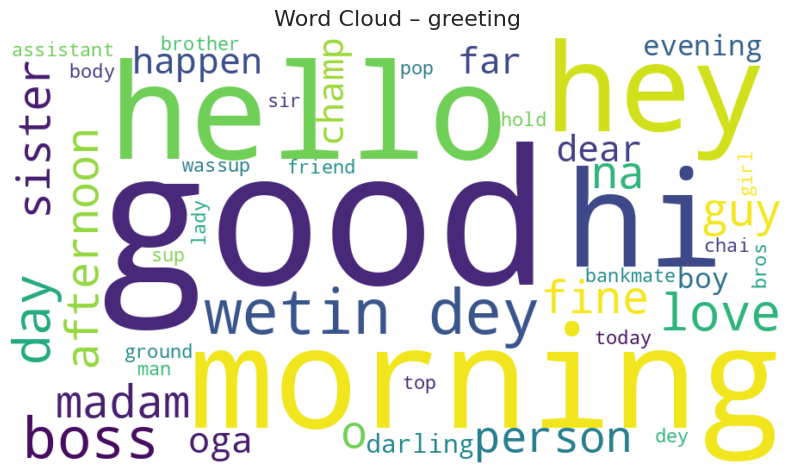

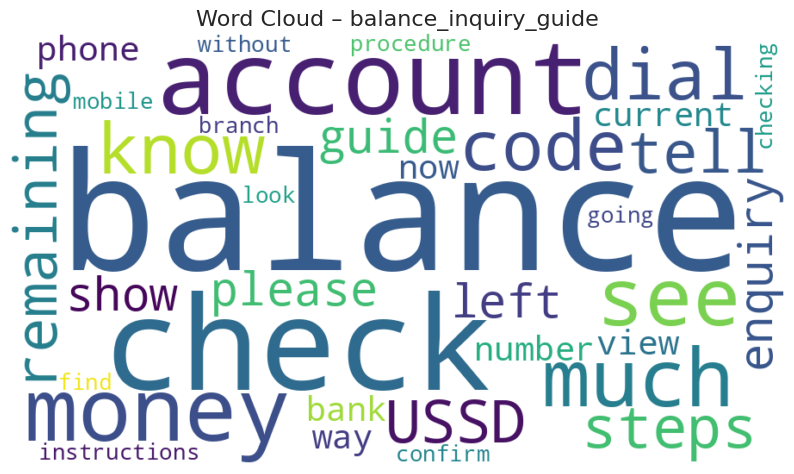

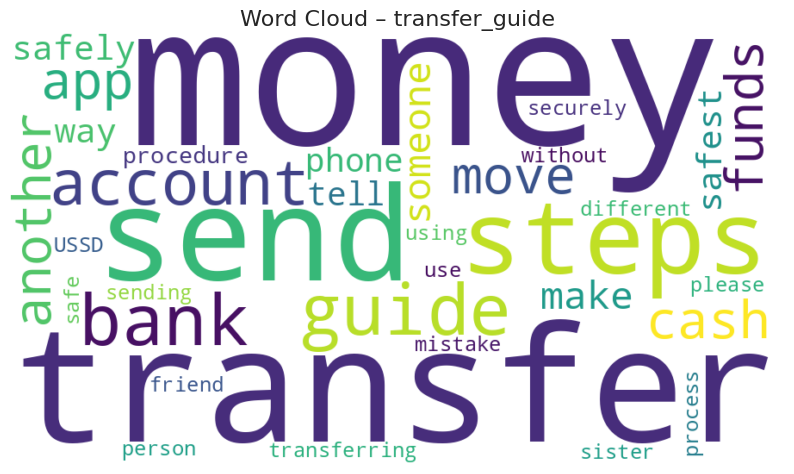

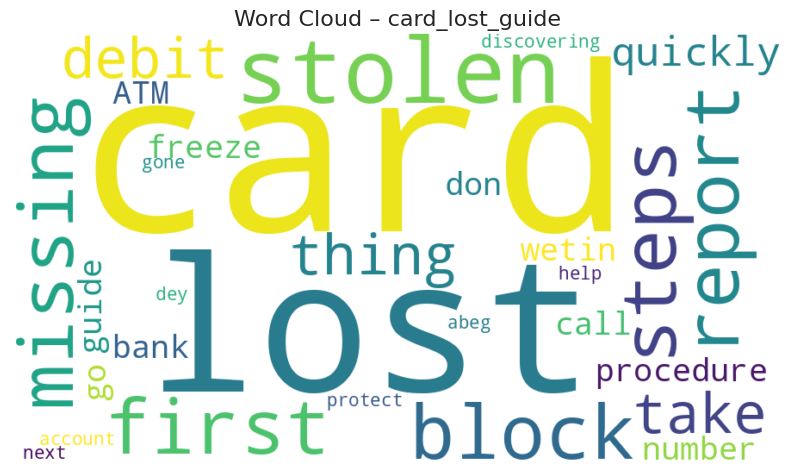

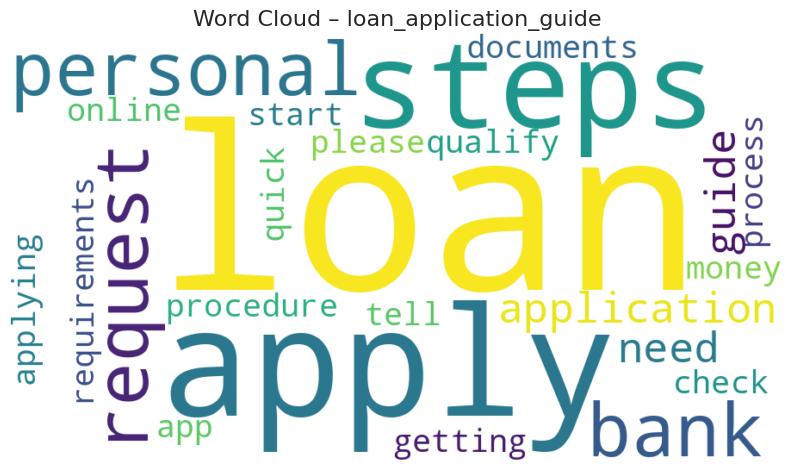

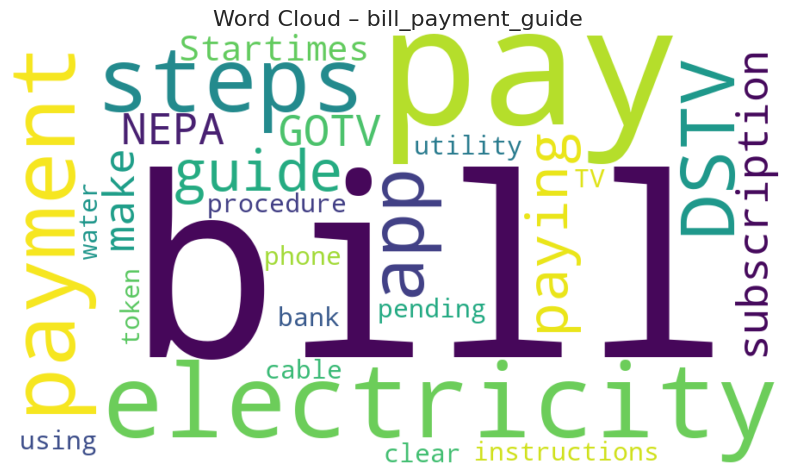

In [ ]:
def generate_wordcloud(intent_name):
    text = " ".join(df[df['intent'] == intent_name]['text'])
    if not text.strip():
        print(f"No text for {intent_name}")
        return
    wc = WordCloud(width=900, height=500, background_color='white',
                   min_font_size=10, max_words=100).generate(text)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud – {intent_name}", fontsize=16)
    plt.show()

print("\nGenerating word clouds for top intents...")
top_intents = df['intent'].value_counts().index[:6]
for intent in top_intents:
    generate_wordcloud(intent)

# Visualization 5: t-SNE of Embeddings


Generating t-SNE visualization (may take 10–40 seconds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


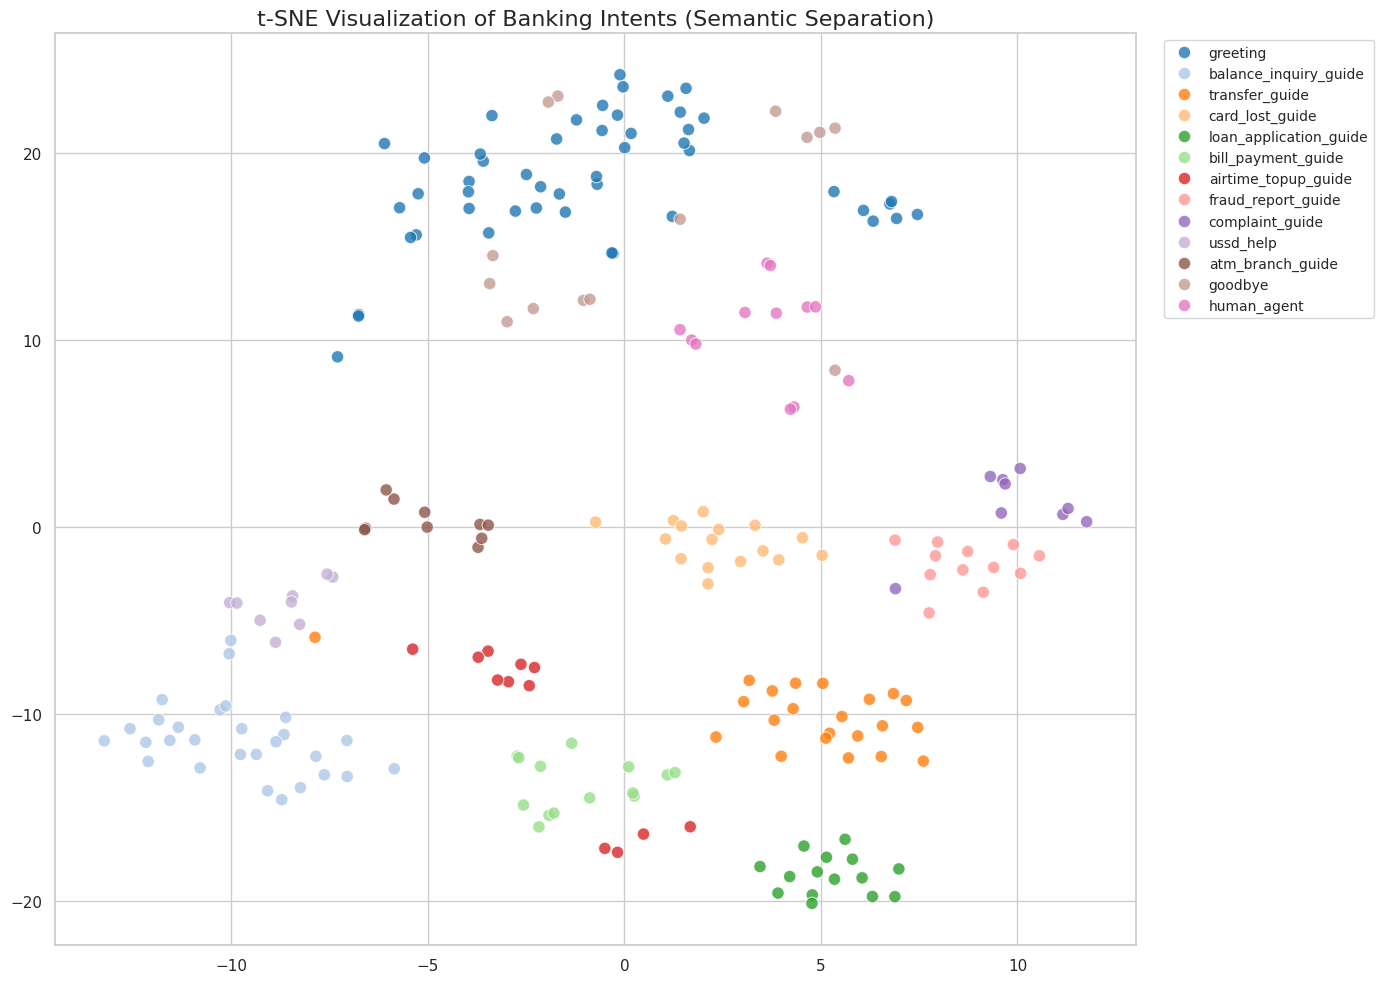

In [ ]:
print("\nGenerating t-SNE visualization (may take 10–40 seconds)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(df['text'].tolist(), show_progress_bar=True)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1],
                hue=df['intent'], palette='tab20', alpha=0.8, s=80)
plt.title("t-SNE Visualization of Banking Intents (Semantic Separation)", fontsize=16)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# Save Model

In [ ]:
model_path = "bankmate_assistant_pipeline.joblib"
joblib.dump(pipeline, model_path)
print(f"\nModel saved - {model_path}")


Model saved - bankmate_assistant_pipeline.joblib
